# Stage 2 - v1: EfficientNet-B3 (Optimization Focus)

## 1. Giriş ve Problem Tanımı

Bu notebook, inme arter sınıflandırması (ACA vs MCA vs PCA) projesinin **v1** iterasyonudur. Baseline modelden elde edilen sonuçlar analiz edilmiş ve tespit edilen sorunları çözmek için eğitim stratejisinde iyileştirmeler yapılmıştır.

### Baseline (v0) Sonuçları ve Sorunlar
| Metrik | Baseline Değeri | Hedef | Durum |
|--------|----------------|-------|-------|
| **ACA Recall** | %76.79 | ≥ %85.0 | ❌ **KRİTİK DÜŞÜK** |
| **MCA Recall** | %89.82 | ≥ %85.0 | ✅ Başarılı |
| **PCA Recall** | %91.03 | ≥ %80.0 | ✅ Başarılı |
| **Macro F1** | 0.8400 | ≥ 0.88 | ⚠️ İyileştirilmeli |

**Tespit Edilen Sorunlar:**
1.  **Yanlış Checkpoint Stratejisi:** Baseline model `val_loss`'a göre kaydedildi. Dengesiz veri setlerinde loss düşerken azınlık sınıfı (ACA) performansı artmayabilir.
2.  **Overconfidence (Aşırı Güven):** Model MCA sınıfında çok emin olduğu için loss değerini domine ediyor, ACA hataları loss üzerinde yeterince etki yaratamıyor.
3.  **Local Minima:** `ReduceLROnPlateau` scheduler'ı modeli yerel bir minimuma (local minima) hapsetmiş olabilir.

### v1 Notebook'ta Yapılan Değişiklikler (Optimization Recipe)

Bu versiyonda model mimarisi (EfficientNet-B3) ve veri işleme (Augmentation/Sampler) **sabit tutulmuş**, sadece eğitim dinamikleri değiştirilmiştir:

1.  **Metric-Based Checkpointing:** Model artık `val_loss` en düşük olduğunda değil, **`val_macro_f1` en yüksek olduğunda** kaydedilecek. Bu, ACA sınıfının başarısını doğrudan ödüllendirir.
2.  **Label Smoothing (0.1):** CrossEntropyLoss'a `label_smoothing=0.1` parametresi eklendi. Bu, modelin tahminlerinde %100 emin olmasını engelleyerek (hard targets yerine soft targets) genelleme yeteneğini artırır.
3.  **Cosine Annealing Scheduler:** `ReduceLROnPlateau` yerine `CosineAnnealingWarmRestarts` kullanıldı. Learning rate periyodik olarak resetlenerek modelin daha iyi çözüm noktaları bulması hedeflendi.


## Bölüm 1: Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from collections import Counter

# Seed Setting
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Bölüm 2: Sabitler ve Hiperparametreler

In [2]:
# --- PATHS ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# --- CLASS INFO ---
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# --- HYPERPARAMETERS (v1) ---
IMG_SIZE = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100

# v1 Değişikliği: Label Smoothing katsayısı
LABEL_SMOOTHING = 0.1 

# v1 Değişikliği: Scheduler Parametreleri (Cosine Annealing)
T_0 = 10      # İlk restart periyodu (epoch)
T_MULT = 2    # Her restartta periyot katlanma oranı (10 -> 20 -> 40...)

# Split Ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f'=== Stage 2 - v1 Parametreleri ===')
print(f'Model: EfficientNet-B3')
print(f'Loss: CrossEntropy (Label Smoothing: {LABEL_SMOOTHING})')
print(f'Scheduler: CosineAnnealingWarmRestarts (T_0={T_0}, T_mult={T_MULT})')
print(f'Checkpoint Metric: MACRO F1 SCORE (Loss değil)')

=== Stage 2 - v1 Parametreleri ===
Model: EfficientNet-B3
Loss: CrossEntropy (Label Smoothing: 0.1)
Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
Checkpoint Metric: MACRO F1 SCORE (Loss değil)


## Bölüm 3: Veri Hazırlığı (Baseline ile Aynı)

In [3]:
def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths = []
    labels = []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg']
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
            
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# Stratified Split
X_temp, X_test, y_temp, y_test = train_test_split(
    all_image_paths, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED
)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, stratify=y_temp, random_state=SEED
)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 3225, Val: 692, Test: 692


## Bölüm 4: Augmentation & Dataset (Baseline ile Aynı)

In [4]:
# Augmentation (Medikal Güvenli)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Dataset Class
class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform)
val_dataset = StrokeDataset(X_val, y_val, transform=val_transform)
test_dataset = StrokeDataset(X_test, y_test, transform=val_transform)

## Bölüm 5: WeightedRandomSampler & DataLoader

In [5]:
# Class Weights for Sampler
class_counts_train = Counter(y_train)
class_weights_sampler = {c: 1.0 / count for c, count in class_counts_train.items()}
sample_weights = [class_weights_sampler[int(label)] for label in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

## Bölüm 6: Model, Loss ve Optimizer (v1 GÜNCELLEMELERİ)

In [6]:
# --- Model ---
def create_model(num_classes):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, num_classes)
    )
    return model

model = create_model(NUM_CLASSES).to(device)

# --- Loss (v1: Label Smoothing Eklendi) ---
# Overconfidence'ı önlemek için label smoothing kullanıyoruz.
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# --- Optimizer ---
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Scheduler (v1: Cosine Annealing) ---
# Local minima'dan kaçmak için Warm Restarts kullanıyoruz.
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T_0,      # İlk restart 10. epochta
    T_mult=T_MULT, # Sonraki restartlar: 10+20=30, 30+40=70...
    eta_min=1e-6
)

## Bölüm 7: Eğitim Fonksiyonları (v1: F1 Score Takibi)

In [7]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Scheduler step (CosineAnnealing batch bazlı da çalışabilir ama epoch bazlı yapacağız)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = running_loss / total
    accuracy = correct / total
    
    # v1 Eklemesi: Macro F1 hesaplama
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, macro_f1, np.array(all_preds), np.array(all_labels)

## Bölüm 8: Eğitim Döngüsü (v1: F1 Tabanlı Checkpoint)

In [8]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0  # v1: Loss yerine F1 takip ediyoruz (Maximization)
CHECKPOINT_PATH = 'best_model_v1.pth'

print('Stage 2 - v1 Eğitimi Başlıyor...')
print(f'Hedef: Macro F1 skorunu maksimize etmek.')

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, device)
    
    # Scheduler Step (Cosine Annealing epoch sonunda güncellenir)
    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]['lr']
    
    # History Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | LR: {current_lr:.2e}')
    print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}')
    
    # v1 Checkpoint Mantığı: Best Macro F1
    if val_f1 > best_val_f1:
        print(f'  >>> İyileşme! (F1: {best_val_f1:.4f} -> {val_f1:.4f}). Model kaydediliyor...')
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    
    print('-' * 60)

# En iyi modeli yükle
model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f'\nEğitim tamamlandı. En iyi model (Val F1: {best_val_f1:.4f}) yüklendi.')

Stage 2 - v1 Eğitimi Başlıyor...
Hedef: Macro F1 skorunu maksimize etmek.


Epoch 1/100 | LR: 1.00e-04
  Train Loss: 1.0020 | Acc: 49.32%
  Val   Loss: 0.8583 | Acc: 63.87% | F1: 0.5604
  >>> İyileşme! (F1: 0.0000 -> 0.5604). Model kaydediliyor...
------------------------------------------------------------


Epoch 2/100 | LR: 9.76e-05
  Train Loss: 0.8241 | Acc: 66.29%
  Val   Loss: 0.6530 | Acc: 79.48% | F1: 0.7080
  >>> İyileşme! (F1: 0.5604 -> 0.7080). Model kaydediliyor...
------------------------------------------------------------


Epoch 3/100 | LR: 9.05e-05
  Train Loss: 0.7113 | Acc: 74.75%
  Val   Loss: 0.6984 | Acc: 76.01% | F1: 0.6934
------------------------------------------------------------


Epoch 4/100 | LR: 7.96e-05
  Train Loss: 0.6751 | Acc: 77.61%
  Val   Loss: 0.6014 | Acc: 81.36% | F1: 0.7451
  >>> İyileşme! (F1: 0.7080 -> 0.7451). Model kaydediliyor...
------------------------------------------------------------


...

Epoch 96/100 | LR: 7.80e-05
  Train Loss: 0.3515 | Acc: 97.08%
  Val   Loss: 0.4996 | Acc: 89.88% | F1: 0.8276
------------------------------------------------------------


Epoch 97/100 | LR: 7.64e-05
  Train Loss: 0.3500 | Acc: 97.01%
  Val   Loss: 0.4915 | Acc: 90.90% | F1: 0.8515
------------------------------------------------------------


Epoch 98/100 | LR: 7.47e-05
  Train Loss: 0.3546 | Acc: 96.55%
  Val   Loss: 0.4917 | Acc: 90.46% | F1: 0.8280
------------------------------------------------------------


Epoch 99/100 | LR: 7.30e-05
  Train Loss: 0.3496 | Acc: 97.29%
  Val   Loss: 0.4845 | Acc: 90.46% | F1: 0.8409
------------------------------------------------------------


Epoch 100/100 | LR: 7.12e-05
  Train Loss: 0.3522 | Acc: 97.11%
  Val   Loss: 0.4780 | Acc: 91.18% | F1: 0.8466
------------------------------------------------------------

Eğitim tamamlandı. En iyi model (Val F1: 0.8664) yüklendi.


## Bölüm 9: Eğitim Grafikleri

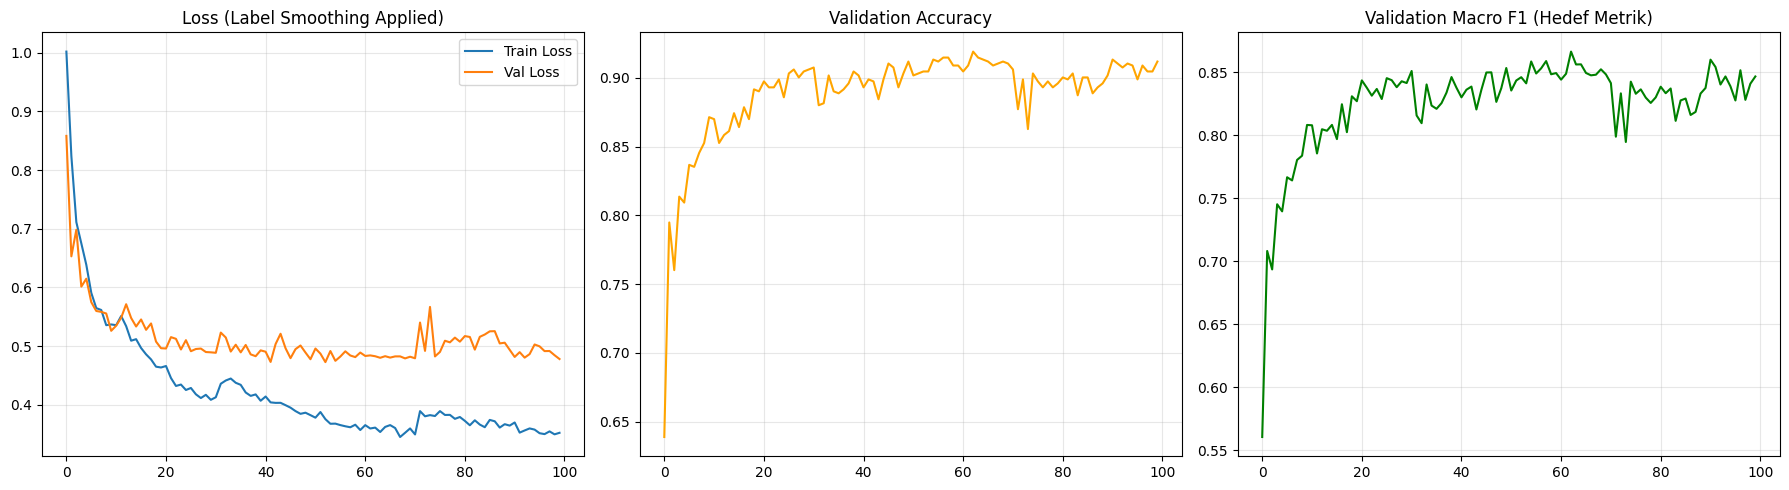

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (Label Smoothing Applied)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['val_acc'], label='Val Acc', color='orange')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[2].set_title('Validation Macro F1 (Hedef Metrik)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bölüm 10: Test ve Karşılaştırma

=== Stage 2 - v1 Test Değerlendirmesi ===
Test Accuracy: 90.17%
Test Macro F1: 0.8449

Classification Report:
              precision    recall  f1-score   support

         ACA     0.7593    0.7321    0.7455        56
         MCA     0.9457    0.9226    0.9340       491
         PCA     0.8176    0.8966    0.8553       145

    accuracy                         0.9017       692
   macro avg     0.8409    0.8504    0.8449       692
weighted avg     0.9038    0.9017    0.9023       692



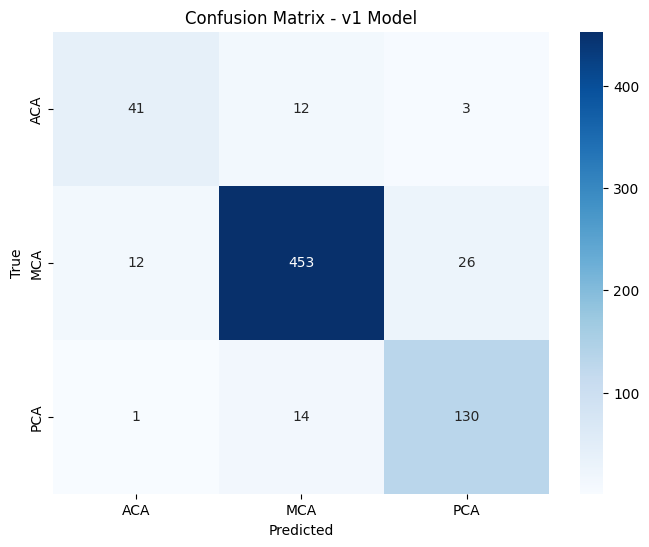


=== v1 vs Baseline Karşılaştırması ===
ACA Recall Hedef: ≥ 0.85
Baseline ACA Recall: 0.7679
v1 ACA Recall:       0.7321
❌ BAŞARISIZ: ACA Recall iyileşmedi, v2 stratejisi (Focal Loss) düşünülmeli.


In [10]:
print('=== Stage 2 - v1 Test Değerlendirmesi ===')

test_loss, test_acc, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, device)

print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Macro F1: {test_f1:.4f}')

# Classification Report
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - v1 Model')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# --- Baseline ile Karşılaştırma ---
recall_per_class = recall_score(test_labels, test_preds, average=None)
aca_recall = recall_per_class[0]

print('\n=== v1 vs Baseline Karşılaştırması ===')
print(f'ACA Recall Hedef: ≥ 0.85')
print(f'Baseline ACA Recall: 0.7679')
print(f'v1 ACA Recall:       {aca_recall:.4f}')

if aca_recall > 0.7679:
    print('✅ BAŞARILI: ACA Recall değerinde iyileşme sağlandı.')
else:
    print('❌ BAŞARISIZ: ACA Recall iyileşmedi, v2 stratejisi (Focal Loss) düşünülmeli.')